# Notebook 3 – Market Trends Analysis
This notebook analyses the price gaps (actual – predicted) to identify market patterns, over‑/under‑priced segments, and temporal trends. It uses the predictions from the tuned RandomForest model.

# 1. Setup and Imports

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# Plotting style
sns.set_theme(style='whitegrid')
plt.rcParams['figure.dpi'] = 120
plt.rcParams['axes.titlesize'] = 13
plt.rcParams['axes.labelsize'] = 11

# 2. Load Predictions

In [2]:
# Load the test predictions saved from the price prediction notebook
test_results = pd.read_csv('test_predictions.csv')

# Check the data
print(test_results.head())
print(test_results.shape)

   surface  pieces  text_vue_mer  text_meuble  text_neuf  text_standing  \
0      NaN     2.0             0            0          0              0   
1      NaN     3.0             0            1          0              0   
2      NaN     4.0             0            0          0              0   
3     70.0     2.0             0            1          0              0   
4     56.0     2.0             0            0          0              0   

   text_luxe  text_terrasse  text_jardin  text_piscine  ...  has_jardin  \
0          0              0            0             0  ...         0.0   
1          0              1            0             0  ...         0.0   
2          0              1            0             0  ...         0.0   
3          0              0            0             0  ...         0.0   
4          0              1            1             0  ...         1.0   

   has_terrasse  has_balcon  has_ascenseur  price_per_sqm_ville  \
0           0.0         1.0    

# 3. Aggregate Trends by City (ville)

In [3]:
# Group by ville
city_stats = test_results.groupby('ville').agg(
    avg_actual=('actual_price', 'mean'),
    avg_pred=('predicted_price', 'mean'),
    avg_gap=('price_gap', 'mean'),
    avg_gap_pct=('price_gap_pct', 'mean'),
    count=('actual_price', 'count')
).sort_values('count', ascending=False)

# Show top 10 cities by count
print(city_stats.head(10))

                  avg_actual       avg_pred      avg_gap  avg_gap_pct  count
ville                                                                       
Carthage         5449.557427    3270.371875  2179.185552   -15.242697   1306
Hammamet       131001.479601  121768.058682  9233.420920   -15.023772   1103
Marsa            2442.390566    2249.979290   192.411276    -4.109262    530
La Marsa        50362.306878   51357.781734  -995.474856    -7.364082    378
La Soukra       47805.921196   47189.390251   616.530944    -1.098577    368
Hammamet Nord    1651.036913    1510.493731   140.543182   -17.198297    298
Ain Zaghouan    36358.143460   32394.136737  3964.006723    -0.738520    237
Soukra           1276.587629    1156.956138   119.631491    -4.639102    194
L'Aouina         1175.701571    1124.910023    50.791547    -1.314040    191
Gammarth         3981.481481    3821.015301   160.466181    -5.438424    189


# 4. Visualise Top 10 Cities by Average Percentage Gap

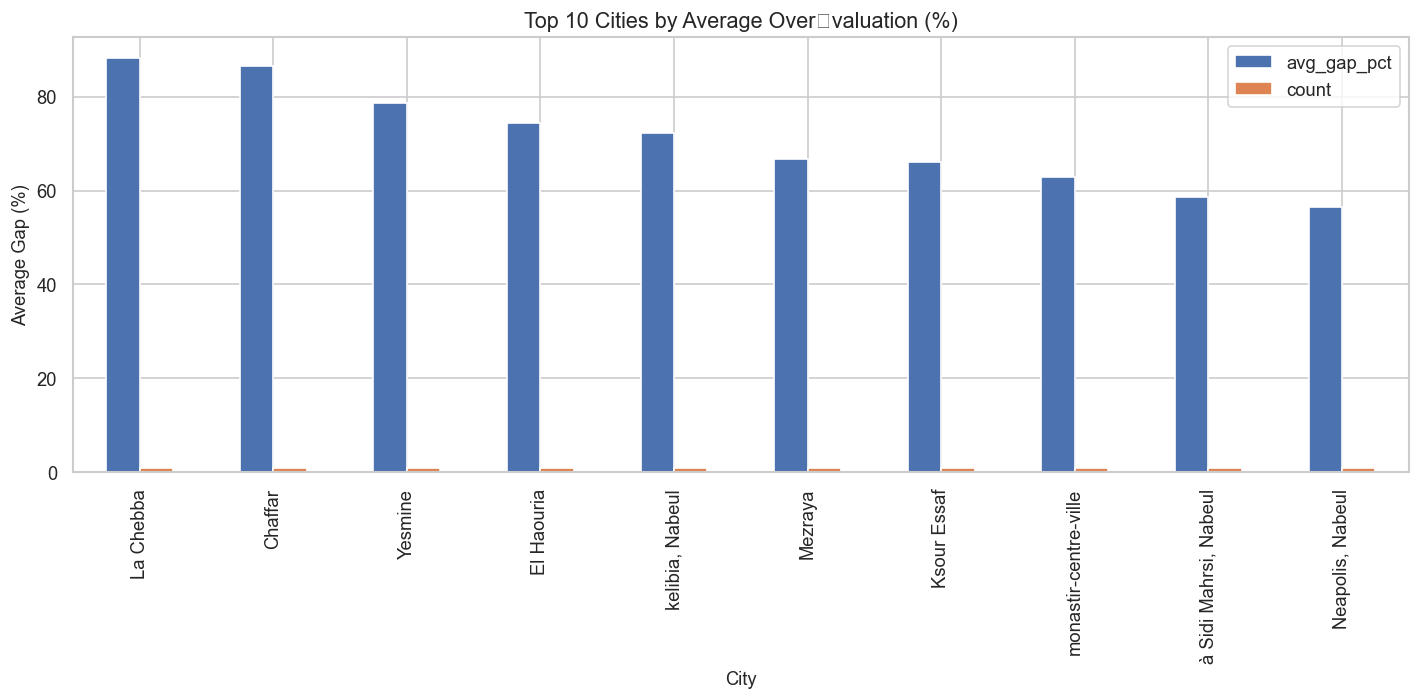

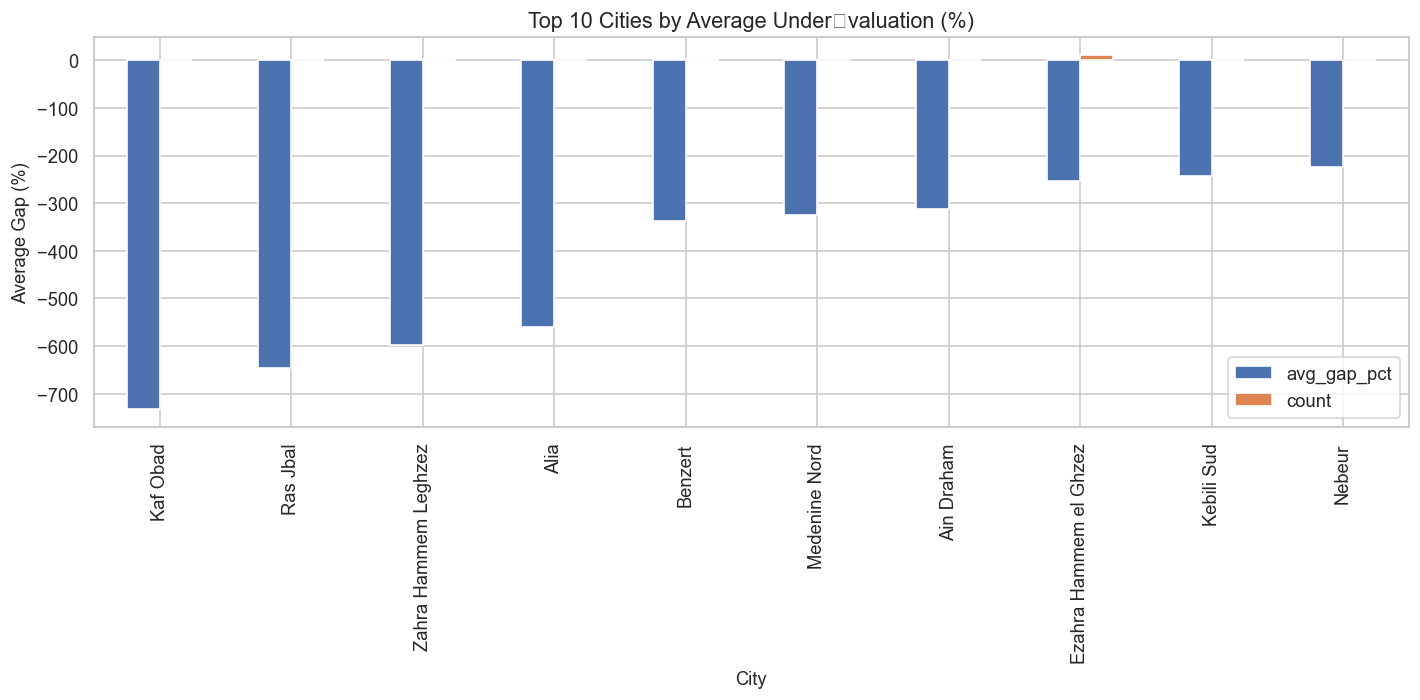

In [4]:
# Get top 10 cities with highest average positive gap (over‑priced)
top_overpriced = city_stats.sort_values('avg_gap_pct', ascending=False).head(10)
top_overpriced[['avg_gap_pct', 'count']].plot(kind='bar', figsize=(12,6))
plt.title('Top 10 Cities by Average Over‑valuation (%)')
plt.xlabel('City')
plt.ylabel('Average Gap (%)')
plt.tight_layout()
plt.show()

# Top 10 cities with highest average negative gap (under‑priced)
top_underpriced = city_stats.sort_values('avg_gap_pct').head(10)
top_underpriced[['avg_gap_pct', 'count']].plot(kind='bar', figsize=(12,6))
plt.title('Top 10 Cities by Average Under‑valuation (%)')
plt.xlabel('City')
plt.ylabel('Average Gap (%)')
plt.tight_layout()
plt.show()

# 5. Trends by Property Type and Contract

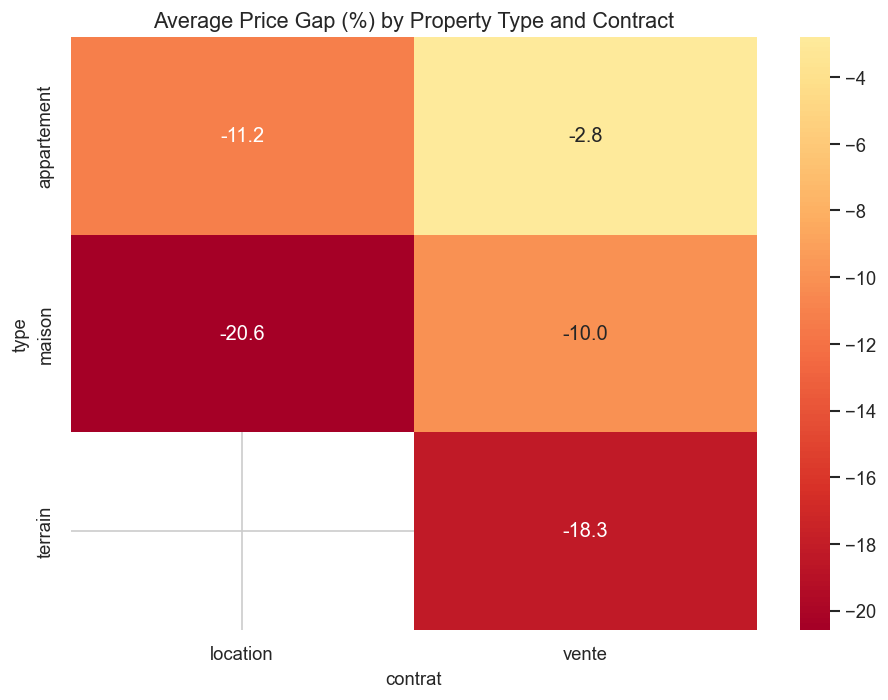

In [5]:
type_contrat = test_results.groupby(['type', 'contrat']).agg(
    avg_gap_pct=('price_gap_pct', 'mean'),
    count=('actual_price', 'count')
).reset_index()

# Pivot for heatmap
pivot = type_contrat.pivot(index='type', columns='contrat', values='avg_gap_pct')
plt.figure(figsize=(8,6))
sns.heatmap(pivot, annot=True, fmt='.1f', cmap='RdYlGn', center=0)
plt.title('Average Price Gap (%) by Property Type and Contract')
plt.tight_layout()
plt.show()

# 6. Time Series Analysis (Seasonality)
### 1. Prepare date column

In [11]:
# Convert date_publication to datetime (if not already done)
test_results['date'] = pd.to_datetime(test_results['date_publication'], errors='coerce')
test_results['year'] = test_results['date'].dt.year
test_results['month'] = test_results['date'].dt.month

# Define season (optional)
def get_season(month):
    if month in [12, 1, 2]:
        return 'Winter'
    elif month in [3, 4, 5]:
        return 'Spring'
    elif month in [6, 7, 8]:
        return 'Summer'
    else:
        return 'Autumn'

test_results['season'] = test_results['month'].apply(get_season)

KeyError: 'date_publication'

### 2. Monthly average gap by contract

In [ ]:
monthly_gap = test_results.groupby(['month', 'contrat']).agg(
    avg_gap_pct=('price_gap_pct', 'mean'),
    count=('price_gap_pct', 'count')
).reset_index()

# Pivot for easier plotting
monthly_pivot = monthly_gap.pivot(index='month', columns='contrat', values='avg_gap_pct')

# Plot
plt.figure(figsize=(12,6))
monthly_pivot.plot(marker='o')
plt.title('Average Price Gap (%) by Month and Contract')
plt.xlabel('Month')
plt.ylabel('Average Gap (%)')
plt.xticks(range(1,13), ['Jan','Feb','Mar','Apr','May','Jun','Jul','Aug','Sep','Oct','Nov','Dec'])
plt.grid(True)
plt.legend(title='Contract')
plt.tight_layout()
plt.show()

### 3; Seasonal boxplots (focus on location)

In [12]:
# Filter rental properties
location_data = test_results[test_results['contrat'] == 'location']

plt.figure(figsize=(10,6))
sns.boxplot(data=location_data, x='season', y='price_gap_pct', order=['Winter','Spring','Summer','Autumn'])
plt.title('Price Gap Distribution by Season (Rentals)')
plt.xlabel('Season')
plt.ylabel('Price Gap (%)')
plt.axhline(0, color='red', linestyle='--')
plt.tight_layout()
plt.show()

ValueError: Could not interpret value `season` for `x`. An entry with this name does not appear in `data`.

<Figure size 1200x720 with 0 Axes>

### 4. Time series of predicted vs actual for a specific city

In [ ]:
city_example = 'Hammamet'
city_data = test_results[(test_results['ville'] == city_example) & (test_results['contrat'] == 'location')]
city_data = city_data.sort_values('date')

plt.figure(figsize=(12,6))
plt.plot(city_data['date'], city_data['actual_price'], label='Actual Price', marker='o', linestyle='-')
plt.plot(city_data['date'], city_data['predicted_price'], label='Predicted Price', marker='x', linestyle='--')
plt.title(f'Actual vs Predicted Price for Rentals in {city_example}')
plt.xlabel('Date')
plt.ylabel('Price (TND)')
plt.legend()
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

###

# 7. Impact of Amenities

In [6]:
# List of binary features (add more if needed)
amenities = ['has_climatisation', 'has_chaffage', 'has_parking', 'has_jardin',
             'has_terrasse', 'has_balcon', 'has_ascenseur']

# For each amenity, compute average gap when present vs absent
for col in amenities:
    present = test_results[test_results[col] == 1]['price_gap_pct']
    absent = test_results[test_results[col] == 0]['price_gap_pct']
    print(f"{col}: present avg gap = {present.mean():.2f}%, absent avg gap = {absent.mean():.2f}%")

has_climatisation: present avg gap = -9.11%, absent avg gap = -16.81%
has_chaffage: present avg gap = -6.67%, absent avg gap = -18.35%
has_parking: present avg gap = -8.20%, absent avg gap = -15.62%
has_jardin: present avg gap = -12.33%, absent avg gap = -14.00%
has_terrasse: present avg gap = -10.98%, absent avg gap = -14.39%
has_balcon: present avg gap = -7.65%, absent avg gap = -15.41%
has_ascenseur: present avg gap = -9.65%, absent avg gap = -14.09%


# 8. Price Gap by Surface Bins

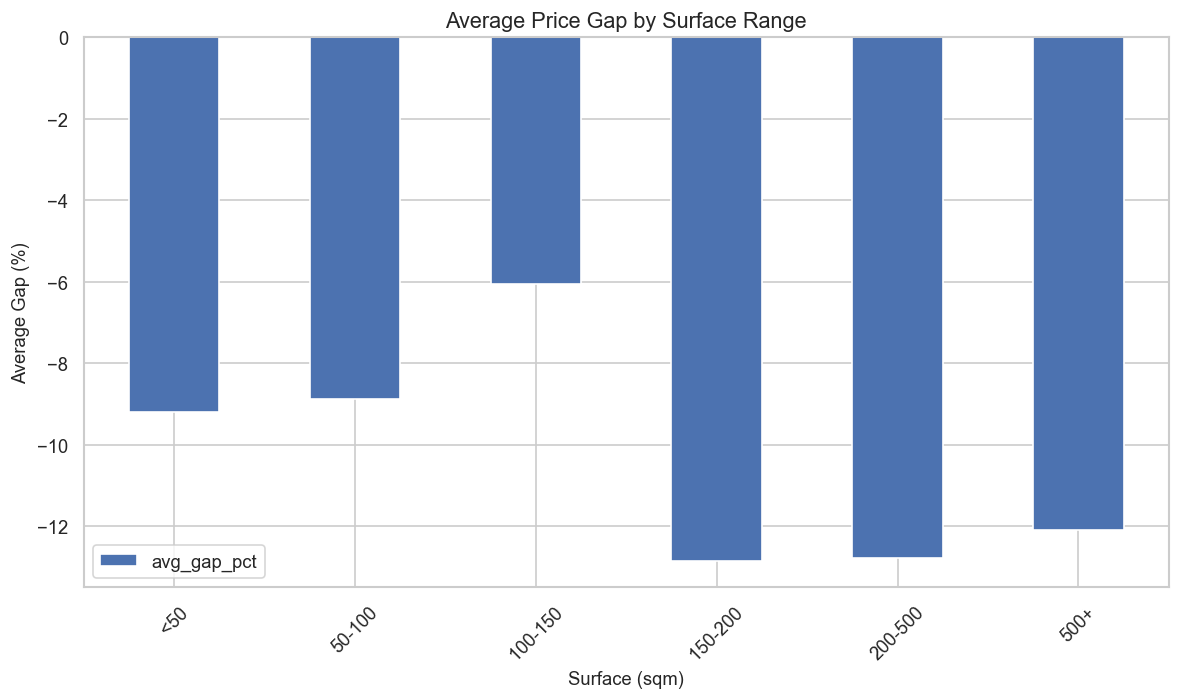

In [7]:
# Create surface bins (adjust bins as needed)
bins = [0, 50, 100, 150, 200, 500, np.inf]
labels = ['<50', '50-100', '100-150', '150-200', '200-500', '500+']
test_results['surface_bin'] = pd.cut(test_results['surface'], bins=bins, labels=labels)

surface_stats = test_results.groupby('surface_bin').agg(
    avg_gap_pct=('price_gap_pct', 'mean'),
    count=('actual_price', 'count')
)

surface_stats.plot(kind='bar', y='avg_gap_pct', figsize=(10,6))
plt.title('Average Price Gap by Surface Range')
plt.xlabel('Surface (sqm)')
plt.ylabel('Average Gap (%)')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# 9. Temporal Trends

In [8]:
# Convert date_publication to datetime if present
if 'date_publication' in test_results.columns:
    test_results['date'] = pd.to_datetime(test_results['date_publication'], errors='coerce')
    test_results['year_month'] = test_results['date'].dt.to_period('M')
    time_stats = test_results.groupby('year_month').agg(
        avg_gap_pct=('price_gap_pct', 'mean'),
        count=('actual_price', 'count')
    ).dropna()

    # Plot
    time_stats['avg_gap_pct'].plot(figsize=(12,6))
    plt.title('Average Price Gap Over Time')
    plt.xlabel('Month')
    plt.ylabel('Average Gap (%)')
    plt.tight_layout()
    plt.show()
else:
    print("Date column not available; skipping time trend analysis.")

Date column not available; skipping time trend analysis.


# 10. Identify Extreme Outliers (Mispriced Properties)

In [9]:
# Over‑priced properties (price > predicted by more than 50%)
overpriced = test_results[test_results['price_gap_pct'] > 50].sort_values('price_gap_pct', ascending=False)
print(f"Number of overpriced properties (>50% over): {len(overpriced)}")
print(overpriced[['surface', 'type', 'ville', 'actual_price', 'predicted_price', 'price_gap_pct']].head(10))

# Under‑priced properties (price < predicted by more than 50%)
underpriced = test_results[test_results['price_gap_pct'] < -50].sort_values('price_gap_pct')
print(f"\nNumber of underpriced properties (< -50% under): {len(underpriced)}")
print(underpriced[['surface', 'type', 'ville', 'actual_price', 'predicted_price', 'price_gap_pct']].head(10))

Number of overpriced properties (>50% over): 573
       surface         type          ville  actual_price  predicted_price  \
6300     100.0       maison       Carthage        6000.0       591.204261   
870        NaN       maison      La Chebba        2500.0       294.036932   
11409    100.0       maison   Behi Ladgham        5000.0       599.965771   
11919      NaN  appartement        Kelibia        2500.0       325.509645   
9297     211.0      terrain         Raoued      738500.0     96585.208048   
2006       NaN       maison        Chaffar        7000.0       949.404385   
5183       NaN  appartement        Kelibia        2500.0       352.168954   
1591       NaN       maison  Hamem laghzez        2500.0       354.589225   
9585     300.0      terrain        Kelibia      480000.0     69780.869805   
3121       NaN       maison        Kelibia        2500.0       365.992066   

       price_gap_pct  
6300       90.146596  
870        88.238523  
11409      88.000685  
11919      

# 10. Export Aggregated Results

In [10]:
city_stats.to_csv('city_stats.csv')
type_contrat.to_csv('type_contrat_stats.csv')
surface_stats.to_csv('surface_stats.csv')
print("Aggregated results saved.")

Aggregated results saved.
